# Qué cambió entre la Intercensal 2015 y la 2025

Las dos encuestas no usan las mismas geografías ni los mismos códigos. La API trae una tabla curada de indicadores equivalentes y solo compara a nivel nacional y por entidad.

**Regla de oro:** compara solo con `/evolucion`. Los pares `aproximada` traen una advertencia y los `no_comparable` (como agua entubada, que cambió de definición) vienen aparte y no se deben comparar.

Requisitos: `pip install pandas matplotlib`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

API = "https://eic.datzin.com.mx/api"
# Algunos proxies (p. ej. Cloudflare) bloquean el user-agent por defecto de pandas; mandamos uno propio.
OPC = {"User-Agent": "eic-ejemplos"}

# Las claves geográficas llevan ceros a la izquierda ("01", "000000000"): se leen como texto.
CLAVES = {c: str for c in ["cvegeo", "cve_ent", "cve_mun", "cve_loc", "cve_distrito", "padre_cvegeo"]}

def csv(ruta, **kw):
    """Lee cualquier ruta de la API con formato=csv como DataFrame."""
    sep = "&" if "?" in ruta else "?"
    return pd.read_csv(f"{API}{ruta}{sep}formato=csv", storage_options=OPC, dtype=CLAVES, **kw)

def js(ruta):
    """Lee una ruta de la API como JSON (para respuestas anidadas)."""
    return pd.read_json(f"{API}{ruta}", storage_options=OPC, typ="series")

pd.set_option("display.max_colwidth", 80)

## 1. La tabla de equivalencias

In [2]:
eq = csv("/equivalencias")
eq.tipo.value_counts()

tipo
exacta           23
aproximada       10
no_comparable     5
Name: count, dtype: int64

In [3]:
eq[eq.tipo != "exacta"][["codigo_2015", "codigo_2025", "tipo", "nota"]]

,codigo_2015,codigo_2025,tipo,nota
4,IND_053,PROM_HNV,no_comparable,Universos distintos: 2015 mide a mujeres de 15 a 49 años; 2025 a mujeres de ...
5,IND_054,PCN_HF,no_comparable,Universos distintos: 2015 mide a mujeres de 15 a 49 años; 2025 a mujeres de ...
10,IND_061,PCN_VPH_AGUADV,no_comparable,2015 cuenta solo agua entubada dentro de la vivienda; 2025 incluye la que ll...
11,IND_062,PCN_VPH_DRENAJ,aproximada,El diccionario 2015 no detalla los destinos del drenaje; 2025 incluye red pú...
12,IND_063,PCN_VPH_EXCSA,aproximada,2025 incluye letrina (pozo u hoyo).
16,IND_068,PCN_VPH_PC,aproximada,2015 solo cuenta computadora; 2025 incluye laptop o tablet.
21,IND_075,PCN_VPH_PROPIA,aproximada,2025 incluye viviendas que se están pagando.
23,IND_079,PCN_P15YM_SE,aproximada,2025 cuenta como sin instrucción a quien solo aprobó preescolar.
24,IND_080,PCN_P15YM_EB,aproximada,2025 incluye estudios técnicos o comerciales con primaria o secundaria termi...
25,IND_082,PCN_P15YM_EMS,aproximada,La clasificación de estudios técnicos o comerciales puede diferir entre leva...


## 2. Evolución de una entidad

Un cambio es estadísticamente claro cuando los intervalos de confianza al 90 % de ambos años no se traslapan.

In [4]:
yuc = csv("/evolucion?cve_ent=31")
yuc[["nombre", "tipo", "valor_2015", "valor_2025", "cambio", "intervalos_se_traslapan", "advertencia"]]

,nombre,tipo,valor_2015,valor_2025,cambio,intervalos_se_traslapan,advertencia
0,Porcentaje de población de 12 años y más económicamente activa,exacta,52.02,57.44,5.42,False,NaN
1,Porcentaje de población de 12 años y más no económicamente activa,exacta,47.79,42.30,-5.49,False,NaN
2,Porcentaje de población de 12 años y más económicamente activa ocupada,exacta,98.04,98.49,0.45,False,NaN
3,Porcentaje de población de 15 años y más con educación básica,aproximada,55.05,43.76,-11.29,False,2025 incluye estudios técnicos o comerciales con primaria o secundaria termi...
4,Porcentaje de población de 15 años y más con educación media superior,aproximada,19.91,24.26,4.35,False,La clasificación de estudios técnicos o comerciales puede diferir entre leva...
5,Porcentaje de población de 15 años y más con educación superior,aproximada,18.16,24.39,6.23,False,La clasificación de estudios técnicos o comerciales puede diferir entre leva...
6,Porcentaje de población de 15 años y más sin instrucción,aproximada,6.67,4.77,-1.90,False,2025 cuenta como sin instrucción a quien solo aprobó preescolar.
7,Porcentaje de población de 3 años y más que habla lengua indígena y no habla...,exacta,4.79,3.54,-1.25,False,NaN
8,Porcentaje de población de 3 años y más que habla lengua indígena,exacta,28.89,21.40,-7.49,False,NaN
9,Porcentaje de población que se considera afromexicana o afrodescendiente,aproximada,0.12,2.07,1.95,False,La pregunta de autoadscripción cambió de redacción: 2025 pregunta por afrome...


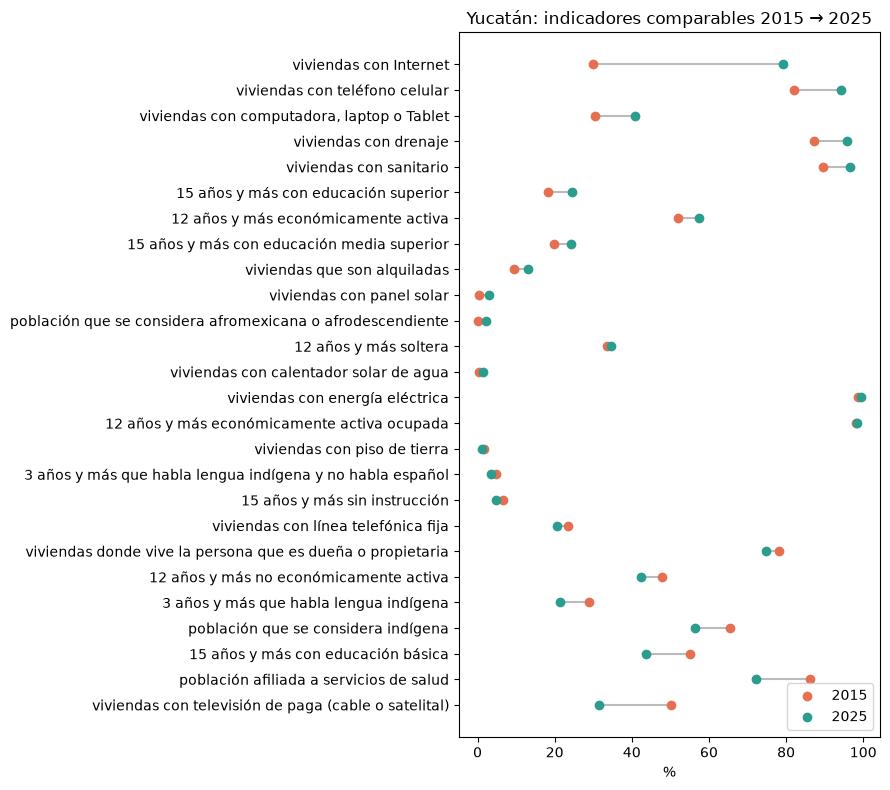

In [5]:
pct = yuc[yuc.nombre.str.startswith("Porcentaje")].sort_values("cambio").reset_index(drop=True)
# etiquetas cortas: "Porcentaje de viviendas particulares habitadas donde se dispone de Internet" -> "viviendas con Internet"
etiqueta = (pct["nombre"].str.replace(r"^Porcentaje de (la )?", "", regex=True)
            .str.replace("viviendas particulares habitadas donde se dispone de ", "viviendas con ")
            .str.replace("viviendas particulares habitadas", "viviendas")
            .str.replace("población de ", ""))
y = range(len(pct))
fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(y, pct["valor_2015"], pct["valor_2025"], color="#bbb")
ax.scatter(pct["valor_2015"], y, label="2015", color="#e76f51", zorder=3)
ax.scatter(pct["valor_2025"], y, label="2025", color="#2a9d8f", zorder=3)
ax.set_yticks(list(y), etiqueta.str[:60])
ax.set_xlabel("%")
ax.set_title("Yucatán: indicadores comparables 2015 → 2025")
ax.legend(loc="lower right")
plt.tight_layout()

## 3. Lo que no se debe comparar

La respuesta JSON trae `no_comparables` con la razón de cada uno.

In [6]:
ev = js("/evolucion?cve_ent=31")
print(ev["como_leer"])
pd.DataFrame(ev["no_comparables"])[["codigo_2015", "codigo_2025", "nombre", "razon"]]

Solo los indicadores de `items` son comparables entre 2015 y 2025; no compares ningún otro aunque tenga un nombre parecido. Los de `no_comparables` cambiaron de definición o de universo: no reportes su cambio. Si un indicador trae `advertencia`, menciónala junto a la cifra. Un cambio es estadísticamente claro solo si `intervalos_se_traslapan` es false.


,codigo_2015,codigo_2025,nombre,razon
0,IND_054,PCN_HF,Porcentaje de hijas o hijos fallecidos de las mujeres de 12 años y más,Universos distintos: 2015 mide a mujeres de 15 a 49 años; 2025 a mujeres de ...
1,IND_121,PCN_PDER_IMSS,Porcentaje de población afiliada a IMSS,Denominadores distintos: 2015 es porcentaje de toda la población; 2025 es po...
2,IND_122,PCN_PDER_ISTE,Porcentaje de población afiliada a ISSSTE,Denominadores distintos: 2015 es porcentaje de toda la población; 2025 es po...
3,IND_061,PCN_VPH_AGUADV,Porcentaje de viviendas particulares habitadas donde se dispone de agua entu...,2015 cuenta solo agua entubada dentro de la vivienda; 2025 incluye la que ll...
4,IND_053,PROM_HNV,Promedio de hijas o hijos nacidos vivos de las mujeres de 12 años y más,Universos distintos: 2015 mide a mujeres de 15 a 49 años; 2025 a mujeres de ...


## 4. Un indicador en las 32 entidades

El crecimiento del acceso a internet, entidad por entidad.

In [7]:
entidades = csv("/entidades").query("cve_ent != '00'")
filas = []
for e in entidades.itertuples():
    ev = csv(f"/evolucion?cve_ent={e.cve_ent}&tema=vivienda")
    filas.append(ev[ev.codigo_2025 == "PCN_VPH_INTER"].assign(entidad=e.nombre))
internet = pd.concat(filas).sort_values("cambio")
internet[["entidad", "valor_2015", "valor_2025", "cambio", "intervalos_se_traslapan"]].tail()

,entidad,valor_2015,valor_2025,cambio,intervalos_se_traslapan
5,Tlaxcala,20.84,69.95,49.11,False
5,Yucatán,29.99,79.29,49.30,False
5,Aguascalientes,35.64,86.79,51.15,False
5,Hidalgo,19.22,70.49,51.27,False
5,Zacatecas,24.02,75.74,51.72,False


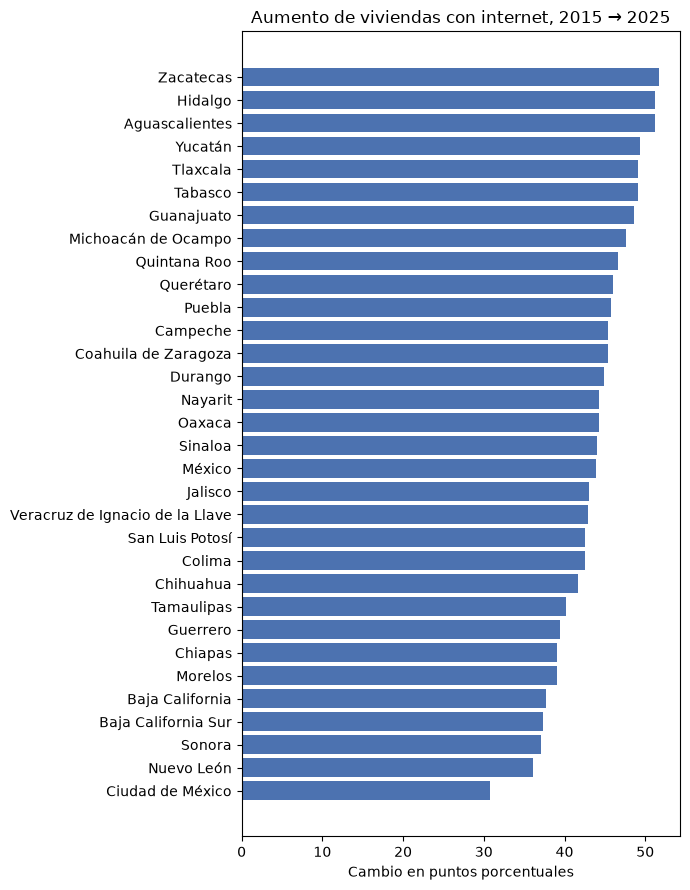

In [8]:
fig, ax = plt.subplots(figsize=(7, 9))
ax.barh(internet["entidad"], internet["cambio"], color="#4C72B0")
ax.set_xlabel("Cambio en puntos porcentuales")
ax.set_title("Aumento de viviendas con internet, 2015 → 2025")
plt.tight_layout()

---
*Fuente: INEGI, Encuesta Intercensal 2015 y 2025. Datos servidos por [EIC API + MCP](https://github.com/zamax14/EIC-API-MCP).*